In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pylcp as pylcp 
import scipy.constants as cts

In [2]:
mass_lab = 173*cts.value('atomic mass constant') # YB-173 mass in kg



klab = 2*np.pi*25068.2222
# Lab wavevector (without 2pi) in cm^{-1}   # Lifetime of 6P_{3/2} state (in seconds)
gammalab = (1.93*1e8)
Blab = -67*1e-3#(v0*cts.hbar*(klab*100))/cts.value('Bohr magneton')
b_0L =  48*1e-3
# (v0*cts.hbar*(klab*100))/cts.value('Bohr magneton')/2
# T # About 15 G/cm is a typical gradient for Rb
L = 16
x0 = 1/klab  # cm
t0 = 1/gammalab  # s
gamma = 1
k = 1
#100*(mass_lab*(v0**2))/(0.5*cts.hbar*(klab*100)*gammalab) +5
print(Blab, L,b_0L)

-0.067 16 0.048


In [67]:
atom = pylcp.atom('7Li')
(atom.gI)

-0.001182213

In [68]:
H_g_D2, mu_q_g_D2 = pylcp.hamiltonians.hyperfine_coupled(
0, 5/2, 0,-0.2592/1836.1526,
    Ahfs = 0, Bhfs=0, Chfs=0,
    muB=1)# ground state 1s0#173-gI factor -0.2592
H_e_D2, mu_q_e_D2 = pylcp.hamiltonians.hyperfine_coupled(
1, 5/2,1.035,-0.2592/1836.1526,
    Ahfs=59.521*1e6/gammalab,Bhfs = 601.87*1e6/gammalab,Chfs= 0,
    muB=1) #excited state 1p1 changed Shfs from 1e6 to 1e7
#changed to yb-174
dijq_D2 = pylcp.hamiltonians.dqij_two_hyperfine_manifolds(0,1, 5/2)

E_e_D2 = np.unique(np.diagonal(H_e_D2))
E_g_D2 = np.unique(np.diagonal(H_g_D2))
hamiltonian_D2 = pylcp.hamiltonian()
hamiltonian_D2.add_H_0_block('g', H_g_D2)
hamiltonian_D2.add_H_0_block('e', H_e_D2)
hamiltonian_D2.add_d_q_block('g', 'e', dijq_D2, gamma = gamma, k = k)
hamiltonian_D2.add_mu_q_block('g', mu_q_g_D2)
hamiltonian_D2.add_mu_q_block('e', mu_q_e_D2
)



In [1]:
49.21+19.21

68.42

In [69]:
t0*cts.value('Bohr magneton')/cts.hbar*20e-3

9.113057050571886

In [70]:
def mag(R,B_0,alpha,l):
   return np.array([0,B_0 + alpha*np.sqrt(1 -R/l),0])

In [101]:
r

[array([0.        , 9.11305705, 0.        ]),
 array([0.       , 8.9907798, 0.       ]),
 array([0.        , 8.86787708, 0.        ]),
 array([0.       , 8.7443392, 0.       ]),
 array([0.        , 8.62015619, 0.        ]),
 array([0.        , 8.49531785, 0.        ]),
 array([0.        , 8.36981369, 0.        ]),
 array([0.        , 8.24363295, 0.        ]),
 array([0.        , 8.11676455, 0.        ]),
 array([0.        , 7.98919714, 0.        ]),
 array([0.        , 7.86091903, 0.        ]),
 array([0.        , 7.73191821, 0.        ]),
 array([0.        , 7.60218233, 0.        ]),
 array([0.        , 7.47169867, 0.        ]),
 array([0.        , 7.34045415, 0.        ]),
 array([0.        , 7.20843531, 0.        ]),
 array([0.        , 7.07562828, 0.        ]),
 array([0.        , 6.94201876, 0.        ]),
 array([0.        , 6.80759204, 0.        ]),
 array([0.        , 6.67233293, 0.        ]),
 array([0.        , 6.53622577, 0.        ]),
 array([0.        , 6.39925442, 0.      

In [125]:
R = np.linspace(0,16,1000)
r = []
for i in R:
    r_n= t0*(cts.value('Bohr magneton')*mag(i,0,53e-3,16)/cts.hbar)
    r.append(r_n)
bf = []
for i in r:
    bf.append(i[1])

In [126]:
k1 = (hamiltonian_D2.return_full_H({'g->e':np.array([0,0,0])},[0,0.1,0])[6:24,6:24])
print(k1)

[[ 1.16562217+0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.06324817+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  1.12424193+0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.07746287+0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  1.0828617 +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.07746287+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  1.04148146+0.j
   0.        +0.j  0.        +0.j  0.

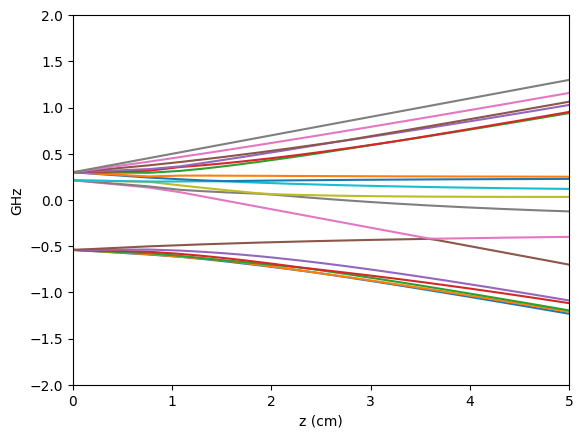

In [127]:
eig = {}
mfn = 0
k = np.diagonal(hamiltonian_D2.return_full_H({'g->e':np.array([0,0,0])},[0,0,0])[6:24,6:24])
for i in range(len(k)):
    eig[f'{i}'] = []
for i in r:
    mfn = mfn+1
    k = np.sort(np.linalg.eigvals(hamiltonian_D2.return_full_H({'g->e':np.array([0,0,0])},i)[6:24,6:24]))
    for j in range(len(k)):
        eig[f'{j}'].append(k[j]*gammalab/1e9)
            
e = 0
n = 0
for i in eig:
    n = n+1
    e = e+1
    plt.plot(bf,eig[f'{i}'],label = e)


#plt.legend()  
plt.xlim([0,5])
plt.ylim([-2,2])
plt.xlabel('z (cm)')
plt.ylabel('GHz')      
plt.show()

In [109]:
cts.value('Bohr magneton')*1

9.2740100783e-24